# SAE Latent Features vs. Graph Motifs (With Degree + Centrality Controls)

This notebook analyzes whether individual SAE latent features correspond to canonical graph motifs,
with **rigorous controls for degree and centrality confounds**.

## What's New:
- **Sanity check**: Quantify topology-motif correlations to assess confounding
- **Partial correlations**: Control for degree + centrality features when computing feature-motif correlations
- **Before/After comparison**: Show how controls affect correlation estimates
- **All original analyses**: Permutation testing, precision/recall, visualizations (now with both bivariate and partial results)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import pointbiserialr
from sklearn.linear_model import LinearRegression
import os

import torch
import torch.nn.functional as F

from sparse_autoencoder import SparseAutoencoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
comparison_sae = pd.read_csv("outputs/sae_config_comparison.csv")
comparison_sae.sort_values(by = "max_rpb_abs", ascending = False)

,latent_dim,k,sparsity_pct,n_features_tested,n_active_features,dead_feature_rate,max_rpb_abs,max_rpb_feature,max_rpb_motif,best_f1,best_f1_feature,best_f1_motif,best_precision,best_recall,test_reconstruction,composite_score,description,significance_tested,n_significant_features,max_significant_rpb
3,256,16,6.25000,48,48,0.812500,0.695156,z126,in_feedback_loop,0.316667,z187,in_feedback_loop,0.950,0.190,1.527824e-08,0.638958,"Medium capacity, moderate sparsity",False,NaN,NaN
2,512,32,6.25000,117,117,0.771484,0.686792,z327,in_feedback_loop,0.316667,z140,in_feedback_loop,0.950,0.190,6.703782e-09,0.645111,"High capacity, low sparsity",True,384.0,0.686792
0,128,16,12.50000,46,46,0.640625,0.686739,z112,in_feedback_loop,0.315000,z9,in_feedback_loop,1.000,0.189,1.883650e-08,0.664156,"Low capacity, moderate sparsity",True,152.0,0.686739
1,256,32,12.50000,89,89,0.652344,0.686187,z221,in_feedback_loop,0.320000,z212,in_feedback_loop,0.960,0.192,5.996504e-09,0.664148,"Medium capacity, low sparsity",True,310.0,0.686187
4,512,8,1.56250,37,37,0.927734,0.680529,z506,in_feedback_loop,0.311667,z205,in_feedback_loop,0.935,0.187,5.993846e-08,0.619923,"High capacity, high sparsity",False,NaN,NaN
5,512,4,0.78125,20,20,0.960938,0.460268,z187,in_feedback_loop,0.306667,z502,in_feedback_loop,0.920,0.184,6.487746e-08,0.573460,"High capacity, very low sparsity",False,NaN,NaN
6,256,8,3.12500,25,25,0.902344,0.417017,z212,in_feedback_loop,0.316667,z212,in_feedback_loop,0.950,0.190,3.566670e-08,0.542498,"Medium capacity, high sparsity",False,NaN,NaN
7,512,16,3.12500,60,60,0.882812,0.397277,z210,in_feedback_loop,0.313333,z210,in_feedback_loop,0.940,0.188,1.541174e-08,0.524522,"High capacity, moderate sparsity",False,NaN,NaN
9,256,4,1.56250,13,13,0.949219,0.356917,z212,in_feedback_loop,0.313333,z212,in_feedback_loop,0.940,0.188,6.309495e-08,0.474201,"Medium capacity, very low sparsity",False,NaN,NaN
8,128,8,6.25000,29,29,0.773438,0.335990,z9,in_feedback_loop,0.315000,z9,in_feedback_loop,0.945,0.189,2.510395e-08,0.480225,"Low capacity, high sparsity",False,NaN,NaN


In [3]:
# SAE configuration (must match trained checkpoint)
INPUT_DIM = 64
LATENT_DIM = 256  # e.g., 128, 256, 512
K = 16        # e.g., 4, 8, 16, 32

# Statistical testing configuration
N_PERMUTATIONS = 1000  # Number of permutations for statistical testing
SIGNIFICANCE_LEVEL = 0.05  # FDR threshold for significance

# Control configuration
CONTROL_FOR_TOPOLOGY = True  # Set to False to disable controls

# Construct checkpoint path based on config
checkpoint_path = f"checkpoints/sae_latent{LATENT_DIM}_k{K}.pt"

activation_dir = Path("outputs/activations/layer3_new/test")
metadata_dir = Path("virtual_graphs/data/all_graphs/graph_motif_metadata")

print("Using checkpoint:", checkpoint_path)
print(f"Permutation testing: {N_PERMUTATIONS} permutations, FDR < {SIGNIFICANCE_LEVEL}")
print(f"Topology controls: {'ENABLED' if CONTROL_FOR_TOPOLOGY else 'DISABLED'}")

Using checkpoint: checkpoints/sae_latent256_k16.pt
Permutation testing: 1000 permutations, FDR < 0.05
Topology controls: ENABLED


In [4]:
# Load SAE model and test graph IDs
model = SparseAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, k=K)
checkpoint = torch.load(checkpoint_path, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✓ Loaded trained SAE model")
print(f"  Architecture: {model.input_dim} -> {model.latent_dim} -> {model.input_dim}")
print(f"  Sparsity: TopK with k={model.k} ({100*model.k/model.latent_dim:.2f}% active)")

test_graph_ids = []
for file in os.listdir("outputs/activations/layer2_new/test"):
    graph_id = int((file.split(".")[0]).split("graph_")[1])
    test_graph_ids.append(graph_id)
    
print(f"Number of test graphs: {len(test_graph_ids)}")

✓ Loaded trained SAE model
  Architecture: 64 -> 256 -> 64
  Sparsity: TopK with k=16 (6.25% active)
Number of test graphs: 400


In [5]:
# Extract SAE latent representations for all test nodes
all_latents = []  # (graph_id, node_idx, z1..z_LATENT_DIM)
all_motifs = []   # motif labels per node

print("Extracting SAE latent representations for test nodes...")
print("Reading from:", activation_dir)
print("Metadata from:", metadata_dir, "")

for graph_id in tqdm(test_graph_ids, desc="Processing test graphs"):
    act_file = activation_dir / f"graph_{graph_id}.pt"
    if not act_file.exists():
        print(f"Warning: Missing activation file for graph {graph_id}")
        continue

    activations = torch.load(act_file, weights_only=True)  # [num_nodes, 64]

    with torch.no_grad():
        latents = model.encode(activations)  # [num_nodes, LATENT_DIM]

    latents_np = latents.cpu().numpy()
    num_nodes = latents_np.shape[0]

    metadata_file = metadata_dir / f"graph_{graph_id}_metadata.csv"
    if not metadata_file.exists():
        print(f"Warning: Missing metadata for graph {graph_id}")
        continue

    df_meta = pd.read_csv(metadata_file, index_col=0)
    if len(df_meta) != num_nodes:
        print(f"Warning: Node count mismatch for graph {graph_id}: {num_nodes} vs {len(df_meta)}")
        continue

    for node_idx in range(num_nodes):
        latent_row = [graph_id, node_idx] + latents_np[node_idx].tolist()
        all_latents.append(latent_row)

        motif_row = df_meta.iloc[node_idx].to_dict()
        motif_row["graph_id"] = graph_id
        motif_row["node_idx"] = node_idx
        all_motifs.append(motif_row)

latent_cols = ["graph_id", "node_idx"] + [f"z{i+1}" for i in range(LATENT_DIM)]
df_latents = pd.DataFrame(all_latents, columns=latent_cols)
df_motifs = pd.DataFrame(all_motifs)

print(f"✓ Extracted latent representations for {len(df_latents)} nodes")
print(f"  Latent features shape: {df_latents.shape}")
print(f"  Motif labels shape: {df_motifs.shape}")

Extracting SAE latent representations for test nodes...
Reading from: outputs/activations/layer3_new/test
Metadata from: virtual_graphs/data/all_graphs/graph_motif_metadata 


Processing test graphs: 100%|██████████| 400/400 [00:00<00:00, 405.32it/s]


✓ Extracted latent representations for 4000 nodes
  Latent features shape: (4000, 258)
  Motif labels shape: (4000, 15)


In [11]:
# Merge latents and motifs into single dataframe
df = pd.merge(df_latents, df_motifs, on=["graph_id", "node_idx"])

motif_types = [
    "in_feedforward_loop",
    "in_feedback_loop",
    "in_single_input_module",
    "in_cascade",
]

# Standardize column names if needed
rename_map = {
    "feedforward_loop": "in_feedforward_loop",
    "feedback_loop": "in_feedback_loop",
    "single_input_module": "in_single_input_module",
    "cascade": "in_cascade",
}
for k, v in rename_map.items():
    if k in df.columns:
        df = df.rename(columns={k: v})

print("Motif distribution in test set:")
for motif in motif_types:
    if motif in df.columns:
        count = df[motif].sum()
        pct = 100 * count / len(df)
        print(f"  {motif}: {count} nodes ({pct:.2f}%)")

# Check for topology features
topo_features = [
    'degree', 'in_degree', 'out_degree',
        'betweenness_centrality', 'in_closeness_centrality',
        'out_closeness_centrality'
]
available_topo = [f for f in topo_features if f in df.columns]

if CONTROL_FOR_TOPOLOGY:
    if len(available_topo) == 0:
        print("\n⚠ WARNING: No topology features found in metadata!")
        print("   Run: python virtual_graphs/compute_node_features_with_centrality.py")
        print("   Disabling topology controls for now...")
        CONTROL_FOR_TOPOLOGY = False
    else:
        print(f"\n✓ Found {len(available_topo)} topology features for controls")
        print(f"  {', '.join(available_topo[:5])}{'...' if len(available_topo) > 5 else ''}")

Motif distribution in test set:
  in_feedforward_loop: 900.0 nodes (22.50%)
  in_feedback_loop: 1000.0 nodes (25.00%)
  in_single_input_module: 896.0 nodes (22.40%)
  in_cascade: 800.0 nodes (20.00%)

✓ Found 6 topology features for controls
  degree, in_degree, out_degree, betweenness_centrality, in_closeness_centrality...


## Sanity Check: Topology-Motif Correlations

Before analyzing SAE features, let's check how much motif membership is predicted by topology alone.
High correlations indicate potential confounding:
- If feedback loops correlate with high PageRank, SAE features detecting feedback loops might just be detecting important nodes
- Partial correlations (next section) remove these topology effects to isolate motif-specific signal

In [12]:
if CONTROL_FOR_TOPOLOGY and len(available_topo) > 0:
    print("="*70)
    print("SANITY CHECK: Topology-Motif Correlations")
    print("="*70)
    print("High correlations indicate potential confounding:")
    print("(SAE features may be detecting topology rather than motif semantics)\n")
    
    # Compute correlations between motifs and topology features
    sanity_results = []
    for motif in motif_types:
        if motif not in df.columns:
            continue
        for topo_feat in available_topo:
            if df[topo_feat].std() == 0:
                continue
            corr, pval = pointbiserialr(df[motif], df[topo_feat])
            sanity_results.append({
                'motif': motif,
                'topo_feature': topo_feat,
                'rpb': corr,
                'pval': pval,
                'rpb_abs': abs(corr)
            })
    
    df_sanity = pd.DataFrame(sanity_results)
    df_sanity_sorted = df_sanity.sort_values('rpb_abs', ascending=False)
    
    print("Top 12 strongest correlations:")
    for _, row in df_sanity_sorted.head(12).iterrows():
        motif_short = row['motif'].replace('in_', '')
        print(f"  {motif_short:20s} ~ {row['topo_feature']:25s}: rpb={row['rpb']:6.3f}, p={row['pval']:.2e}")
    
    # Breakdown by feature type
    print("\nBreakdown by feature type:")
    degree_features = ['degree', 'in_degree', 'out_degree', 'degree_ratio']
    centrality_features = [f for f in available_topo if f not in degree_features]
    
    degree_corrs = df_sanity[df_sanity['topo_feature'].isin(degree_features)]
    centrality_corrs = df_sanity[df_sanity['topo_feature'].isin(centrality_features)]
    
    if len(degree_corrs) > 0:
        max_degree_corr = degree_corrs['rpb_abs'].max()
        print(f"  Degree features: max |rpb|={max_degree_corr:.3f}")
    
    if len(centrality_corrs) > 0:
        max_centrality_corr = centrality_corrs['rpb_abs'].max()
        print(f"  Centrality features: max |rpb|={max_centrality_corr:.3f}")
    
    print("\nInterpretation:")
    max_corr = df_sanity['rpb_abs'].max()
    if max_corr > 0.5:
        print(f"  ⚠ Strong confounding detected (max |rpb|={max_corr:.3f})")
        print(f"    → Partial correlations are CRITICAL for valid interpretation")
    elif max_corr > 0.3:
        print(f"  ⚠ Moderate confounding detected (max |rpb|={max_corr:.3f})")
        print(f"    → Partial correlations recommended")
    else:
        print(f"  ✓ Weak confounding (max |rpb|={max_corr:.3f})")
        print(f"    → Topology controls may not be necessary")
    
    print("="*70 + "\n")
else:
    print("Skipping sanity check (topology controls disabled)\n")

SANITY CHECK: Topology-Motif Correlations
High correlations indicate potential confounding:
(SAE features may be detecting topology rather than motif semantics)

Top 12 strongest correlations:
  cascade              ~ betweenness_centrality   : rpb= 0.667, p=0.00e+00
  feedback_loop        ~ degree                   : rpb= 0.290, p=1.27e-78
  feedforward_loop     ~ degree                   : rpb= 0.271, p=2.50e-68
  feedback_loop        ~ in_degree                : rpb= 0.208, p=1.99e-40
  feedforward_loop     ~ in_degree                : rpb= 0.194, p=2.46e-35
  feedback_loop        ~ betweenness_centrality   : rpb=-0.192, p=1.12e-34
  feedforward_loop     ~ betweenness_centrality   : rpb=-0.180, p=2.38e-30
  single_input_module  ~ betweenness_centrality   : rpb=-0.179, p=3.50e-30
  feedback_loop        ~ out_closeness_centrality : rpb= 0.157, p=1.80e-23
  feedforward_loop     ~ out_closeness_centrality : rpb= 0.146, p=1.29e-20
  feedback_loop        ~ out_degree               : rpb= 

## Point-Biserial Correlation Analysis

Compute both:
1. **Bivariate correlations** (rpb): Raw correlation between SAE feature and motif
2. **Partial correlations** (rpb_partial): Correlation after removing topology effects

If rpb_partial << rpb, the feature was mostly detecting topology, not motif semantics!

In [13]:
def compute_partial_correlation(binary_var, continuous_var, control_vars, df):
    """
    Compute partial point-biserial correlation controlling for confounds.
    
    Uses residualization approach:
    1. Regress continuous_var on control_vars, get residuals
    2. Compute correlation between binary_var and residuals
    """
    # Prepare data
    y_binary = df[binary_var].values
    y_continuous = df[continuous_var].values
    
    # Check for NaN/inf
    valid_mask = np.isfinite(y_continuous) & np.isfinite(y_binary)
    for cv in control_vars:
        valid_mask &= np.isfinite(df[cv].values)
    
    if valid_mask.sum() < 10:  # Need sufficient data
        return np.nan, np.nan
    
    y_binary = y_binary[valid_mask]
    y_continuous = y_continuous[valid_mask]
    X_control = df[control_vars].values[valid_mask]
    
    # Remove NaN rows from controls
    control_valid = np.all(np.isfinite(X_control), axis=1)
    if control_valid.sum() < 10:
        return np.nan, np.nan
    
    y_binary = y_binary[control_valid]
    y_continuous = y_continuous[control_valid]
    X_control = X_control[control_valid]
    
    # Regress out control variables
    try:
        reg = LinearRegression()
        reg.fit(X_control, y_continuous)
        residuals = y_continuous - reg.predict(X_control)
        
        # Compute correlation between binary variable and residuals
        partial_corr, partial_pval = pointbiserialr(y_binary, residuals)
        return partial_corr, partial_pval
    except:
        return np.nan, np.nan


# Compute correlations
latent_features = [f"z{i+1}" for i in range(LATENT_DIM)]
correlations = []

print("Computing point-biserial correlations...")
if CONTROL_FOR_TOPOLOGY and len(available_topo) > 0:
    print(f"  With partial correlations controlling for: {', '.join(available_topo[:3])}...")
else:
    print("  Bivariate correlations only (no controls)")

for motif in motif_types:
    if motif not in df.columns:
        continue
    for z_idx, z_col in enumerate(latent_features):
        if df[z_col].std() == 0:  # Skip constant features
            continue
        
        # Bivariate correlation
        corr, pval = pointbiserialr(df[motif], df[z_col])
        
        result = {
            "feature": z_col,
            "feature_idx": z_idx + 1,
            "motif": motif,
            "rpb": corr,
            "pval": pval,
            "rpb_abs": abs(corr),
        }
        
        # Partial correlation (if controls enabled)
        if CONTROL_FOR_TOPOLOGY and len(available_topo) > 0:
            partial_corr, partial_pval = compute_partial_correlation(
                motif, z_col, available_topo, df
            )
            result['rpb_partial'] = partial_corr
            result['pval_partial'] = partial_pval
            result['rpb_partial_abs'] = abs(partial_corr) if not np.isnan(partial_corr) else np.nan
        
        correlations.append(result)

df_corr = pd.DataFrame(correlations)

print(f"✓ Computed {len(df_corr)} correlations ({len(latent_features)} features × {len(motif_types)} motifs)")

if CONTROL_FOR_TOPOLOGY and 'rpb_partial' in df_corr.columns:
    print("\nCorrelation statistics (bivariate vs partial):")
    print(df_corr[['rpb', 'rpb_partial', 'rpb_abs', 'rpb_partial_abs']].describe())
    
    # Show how much correlations shrink after controls
    valid_partial = df_corr.dropna(subset=['rpb_partial'])
    if len(valid_partial) > 0:
        mean_shrinkage = (valid_partial['rpb_abs'] - valid_partial['rpb_partial_abs']).mean()
        pct_shrinkage = 100 * mean_shrinkage / valid_partial['rpb_abs'].mean()
        print(f"\nAverage correlation shrinkage: {mean_shrinkage:.3f} ({pct_shrinkage:.1f}%)")
        print("  → This is how much topology was confounding the correlations")
else:
    print("\nCorrelation statistics:")
    print(df_corr[["rpb", "rpb_abs", "pval"]].describe())

# Save correlation matrix
corr_matrix = df_corr.pivot(index="feature", columns="motif", values="rpb")
corr_matrix.to_csv("outputs/feature_motif_correlations_with_controls.csv")
print("\n✓ Saved correlation matrix to outputs/feature_motif_correlations_with_controls.csv")

if CONTROL_FOR_TOPOLOGY and 'rpb_partial' in df_corr.columns:
    corr_matrix_partial = df_corr.pivot(index="feature", columns="motif", values="rpb_partial")
    corr_matrix_partial.to_csv("outputs/feature_motif_correlations_partial.csv")
    print("✓ Saved partial correlation matrix to outputs/feature_motif_correlations_partial.csv")

Computing point-biserial correlations...
  With partial correlations controlling for: degree, in_degree, out_degree...
✓ Computed 192 correlations (256 features × 4 motifs)

Correlation statistics (bivariate vs partial):
              rpb  rpb_partial     rpb_abs  rpb_partial_abs
count  192.000000   192.000000  192.000000     1.920000e+02
mean     0.006560    -0.003096    0.122877     1.092499e-01
std      0.162828     0.153665    0.106670     1.078176e-01
min     -0.734928    -0.697276    0.011183     3.573899e-07
25%     -0.085600    -0.116637    0.058237     2.039091e-04
50%     -0.058156    -0.000158    0.085242     1.062758e-01
75%      0.057758     0.000224    0.143160     1.760973e-01
max      0.432075     0.426468    0.734928     6.972762e-01

Average correlation shrinkage: 0.014 (11.1%)
  → This is how much topology was confounding the correlations

✓ Saved correlation matrix to outputs/feature_motif_correlations_with_controls.csv
✓ Saved partial correlation matrix to outputs/

### Comparison: Top Features Before vs After Controls

In [14]:
if CONTROL_FOR_TOPOLOGY and 'rpb_partial' in df_corr.columns:
    print("="*90)
    print("COMPARISON: Top 10 Features (Bivariate vs Partial Correlations)")
    print("="*90)
    
    for motif in motif_types:
        print(f"\n{motif.replace('in_', '').upper()}:")
        print("-" * 90)
        motif_data = df_corr[df_corr['motif'] == motif].copy()
        motif_data = motif_data.dropna(subset=['rpb_partial'])
        
        if len(motif_data) == 0:
            print("  No valid partial correlations")
            continue
        
        # Top 10 by absolute bivariate correlation
        top10 = motif_data.nlargest(10, 'rpb_abs')
        
        print(f"{'Feature':<10} {'rpb':>8} {'rpb_partial':>12} {'Δ':>8} {'% Shrink':>10}")
        print("-" * 90)
        for _, row in top10.iterrows():
            delta = row['rpb_abs'] - row['rpb_partial_abs']
            pct_shrink = 100 * delta / row['rpb_abs'] if row['rpb_abs'] > 0 else 0
            print(f"{row['feature']:<10} {row['rpb']:>8.3f} {row['rpb_partial']:>12.3f} {delta:>8.3f} {pct_shrink:>9.1f}%")
    
    print("\n" + "="*90)
    print("Interpretation:")
    print("  • Large Δ → Feature was mostly detecting topology, not motif")
    print("  • Small Δ → Feature captures motif-specific signal beyond topology")
    print("="*90)

COMPARISON: Top 10 Features (Bivariate vs Partial Correlations)

FEEDFORWARD_LOOP:
------------------------------------------------------------------------------------------
Feature         rpb  rpb_partial        Δ   % Shrink
------------------------------------------------------------------------------------------
z126          0.294        0.426   -0.133     -45.2%
z212         -0.147       -0.221   -0.073     -49.9%
z36          -0.147       -0.217   -0.070     -47.8%
z187         -0.146       -0.219   -0.074     -50.4%
z77          -0.142       -0.206   -0.064     -44.9%
z244         -0.129       -0.194   -0.065     -50.1%
z117         -0.129       -0.186   -0.057     -44.4%
z182         -0.121       -0.169   -0.049     -40.2%
z8           -0.121       -0.180   -0.060     -49.7%
z217         -0.121       -0.173   -0.053     -43.8%

FEEDBACK_LOOP:
------------------------------------------------------------------------------------------
Feature         rpb  rpb_partial        Δ   %

## Permutation Testing for Statistical Significance

Tests significance of **partial correlations** (if controls enabled) or bivariate correlations (if not).

In [15]:
# Determine which correlation to test
use_partial = CONTROL_FOR_TOPOLOGY and 'rpb_partial' in df_corr.columns
test_corr_col = 'rpb_partial' if use_partial else 'rpb'
test_corr_abs_col = 'rpb_partial_abs' if use_partial else 'rpb_abs'

print(f"Running permutation test with {N_PERMUTATIONS} permutations...")
print(f"Testing: {test_corr_col.upper()}")
print("This will take a few minutes...\n")

# Store null distributions
null_distributions = {motif: {f: [] for f in latent_features} for motif in motif_types}

for perm_idx in tqdm(range(N_PERMUTATIONS), desc="Permutations"):
    for motif in motif_types:
        # Shuffle motif labels
        shuffled_labels = df[motif].sample(frac=1, random_state=42+perm_idx).reset_index(drop=True)
        
        for z_col in latent_features:
            if df[z_col].std() == 0:
                continue
            
            # Compute null correlation
            if use_partial:
                # Create temporary dataframe with shuffled labels
                df_temp = df.copy()
                df_temp[motif] = shuffled_labels
                corr_perm, _ = compute_partial_correlation(motif, z_col, available_topo, df_temp)
            else:
                corr_perm, _ = pointbiserialr(shuffled_labels, df[z_col])
            
            if not np.isnan(corr_perm):
                null_distributions[motif][z_col].append(corr_perm)

# Calculate empirical p-values
df_corr['p_empirical'] = 1.0

for idx, row in df_corr.iterrows():
    feature = row['feature']
    motif = row['motif']
    
    if use_partial:
        obs_corr = row['rpb_partial']
        if np.isnan(obs_corr):
            continue
    else:
        obs_corr = row['rpb']
    
    obs_corr_abs = abs(obs_corr)
    
    null_dist = null_distributions[motif][feature]
    if len(null_dist) == 0:
        continue
    
    # Two-tailed test
    p_empirical = (np.abs(null_dist) >= obs_corr_abs).sum() / len(null_dist)
    df_corr.loc[idx, 'p_empirical'] = p_empirical

# FDR correction
from statsmodels.stats.multitest import multipletests

valid_pvals = df_corr['p_empirical'] < 1.0
if valid_pvals.sum() > 0:
    reject, pvals_fdr, _, _ = multipletests(
        df_corr.loc[valid_pvals, 'p_empirical'], 
        alpha=SIGNIFICANCE_LEVEL, 
        method='fdr_bh'
    )
    df_corr.loc[valid_pvals, 'p_fdr'] = pvals_fdr
    df_corr.loc[valid_pvals, 'significant_fdr'] = reject
else:
    df_corr['p_fdr'] = 1.0
    df_corr['significant_fdr'] = False

# Print results
n_significant = df_corr['significant_fdr'].sum()
print(f"\n✓ Permutation testing complete ({test_corr_col})")
print(f"  Significant feature-motif pairs (FDR < {SIGNIFICANCE_LEVEL}): {n_significant}/{len(df_corr)}")

if n_significant > 0:
    print(f"\nTop 10 significant pairs:")
    sig_cols = ['feature', 'motif', test_corr_col, 'p_empirical', 'p_fdr']
    if use_partial:
        sig_cols.insert(3, 'rpb')  # Show bivariate too for comparison
    print(df_corr[df_corr['significant_fdr']].nlargest(10, test_corr_abs_col)[sig_cols])

Running permutation test with 1000 permutations...
Testing: RPB_PARTIAL
This will take a few minutes...



Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Permutations: 100%|██████████| 1000/1000 [32:56<00:00,  1.98s/it]



✓ Permutation testing complete (rpb_partial)
  Significant feature-motif pairs (FDR < 0.05): 122/192

Top 10 significant pairs:


ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [16]:
df_corr

,feature,feature_idx,motif,rpb,pval,rpb_abs,rpb_partial,pval_partial,rpb_partial_abs,p_empirical,p_fdr,significant_fdr
0,z8,8,in_feedforward_loop,-0.120580,1.982992e-14,0.120580,-0.180468,1.247417e-30,0.180468,0.000,0.000000,True
1,z9,9,in_feedforward_loop,-0.094511,2.112432e-09,0.094511,-0.140000,5.818153e-19,0.140000,0.000,0.000000,True
2,z36,36,in_feedforward_loop,-0.146854,1.004305e-20,0.146854,-0.217091,7.107615e-44,0.217091,0.000,0.000000,True
3,z37,37,in_feedforward_loop,-0.111837,1.310106e-12,0.111837,-0.166229,3.548560e-26,0.166229,0.000,0.000000,True
4,z43,43,in_feedforward_loop,-0.012051,4.460768e-01,0.012051,-0.018916,2.316672e-01,0.018916,0.042,0.060098,False
...,...,...,...,...,...,...,...,...,...,...,...,...
187,z235,235,in_cascade,-0.058566,2.105300e-04,0.058566,0.000026,9.986738e-01,0.000026,0.999,0.999000,False
188,z237,237,in_cascade,-0.053320,7.419426e-04,0.053320,0.000043,9.978394e-01,0.000043,0.999,0.999000,False
189,z239,239,in_cascade,-0.018916,2.316690e-01,0.018916,-0.000024,9.987807e-01,0.000024,0.998,0.999000,False
190,z244,244,in_cascade,-0.083956,1.051735e-07,0.083956,-0.000043,9.978388e-01,0.000043,0.999,0.999000,False


## Precision and Recall Analysis

For features with significant correlations (partial if controls enabled).

In [17]:
def compute_precision_recall(df, feature, motif, percentile=95):
    """Compute precision and recall for a feature-motif pair."""
    threshold = np.percentile(df[feature], percentile)
    activated = df[feature] > threshold
    present = df[motif] == 1
    tp = (activated & present).sum()
    precision = tp / activated.sum() if activated.sum() > 0 else 0
    recall = tp / present.sum() if present.sum() > 0 else 0
    return precision, recall, threshold

precision_recall_results = []

print("Computing precision and recall for top features...")

for motif in motif_types:
    if motif not in df.columns:
        continue
    
    # Get top 10 by absolute correlation (partial if available)
    motif_corrs = df_corr[df_corr['motif'] == motif].nlargest(10, test_corr_abs_col)
    
    for _, row in motif_corrs.iterrows():
        feature = row['feature']
        precision, recall, threshold = compute_precision_recall(df, feature, motif)
        
        result = {
            'feature': feature,
            'motif': motif,
            test_corr_col: row[test_corr_col],
            'precision': precision,
            'recall': recall,
            'threshold': threshold,
            'f1_score': 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        }
        
        if use_partial:
            result['rpb'] = row['rpb']  # Include bivariate for comparison
        
        precision_recall_results.append(result)

df_pr = pd.DataFrame(precision_recall_results)

print(f"\n✓ Computed precision/recall for {len(df_pr)} feature-motif pairs")
print(f"\nPrecision/Recall statistics:")
print(df_pr[['precision', 'recall', 'f1_score']].describe())

print(f"\nTop 10 by F1 score:")
display_cols = ['feature', 'motif', test_corr_col, 'precision', 'recall', 'f1_score']
if use_partial:
    display_cols.insert(3, 'rpb')
print(df_pr.nlargest(10, 'f1_score')[display_cols])

Computing precision and recall for top features...

✓ Computed precision/recall for 40 feature-motif pairs

Precision/Recall statistics:
       precision     recall   f1_score
count  40.000000  40.000000  40.000000
mean    0.238375   0.049175   0.081458
std     0.380447   0.075850   0.126479
min     0.000000   0.000000   0.000000
25%     0.000000   0.000000   0.000000
50%     0.000000   0.000000   0.000000
75%     0.220000   0.055000   0.088000
max     0.950000   0.190000   0.316667

Top 10 by F1 score:
   feature             motif  rpb_partial       rpb  precision  recall  \
12    z187  in_feedback_loop     0.361615  0.430363      0.950  0.1900   
11    z212  in_feedback_loop     0.363633  0.432075      0.945  0.1890   
13     z36  in_feedback_loop     0.357621  0.422971      0.935  0.1870   
17      z8  in_feedback_loop     0.298390  0.356909      0.935  0.1870   
19    z154  in_feedback_loop     0.285953  0.343556      0.935  0.1870   
15    z244  in_feedback_loop     0.319807  0.38

In [18]:
# Save all results
df_corr.to_csv("outputs/latent_correlations_with_controls.csv", index=False)
df_pr.to_csv("outputs/precision_recall_with_controls.csv", index=False)
print("✓ Saved results:")
print("  - outputs/latent_correlations_with_controls.csv")
print("  - outputs/precision_recall_with_controls.csv")

✓ Saved results:
  - outputs/latent_correlations_with_controls.csv
  - outputs/precision_recall_with_controls.csv


## Visualizations

All plots now show **partial correlations** (if controls enabled) to reflect topology-controlled results.

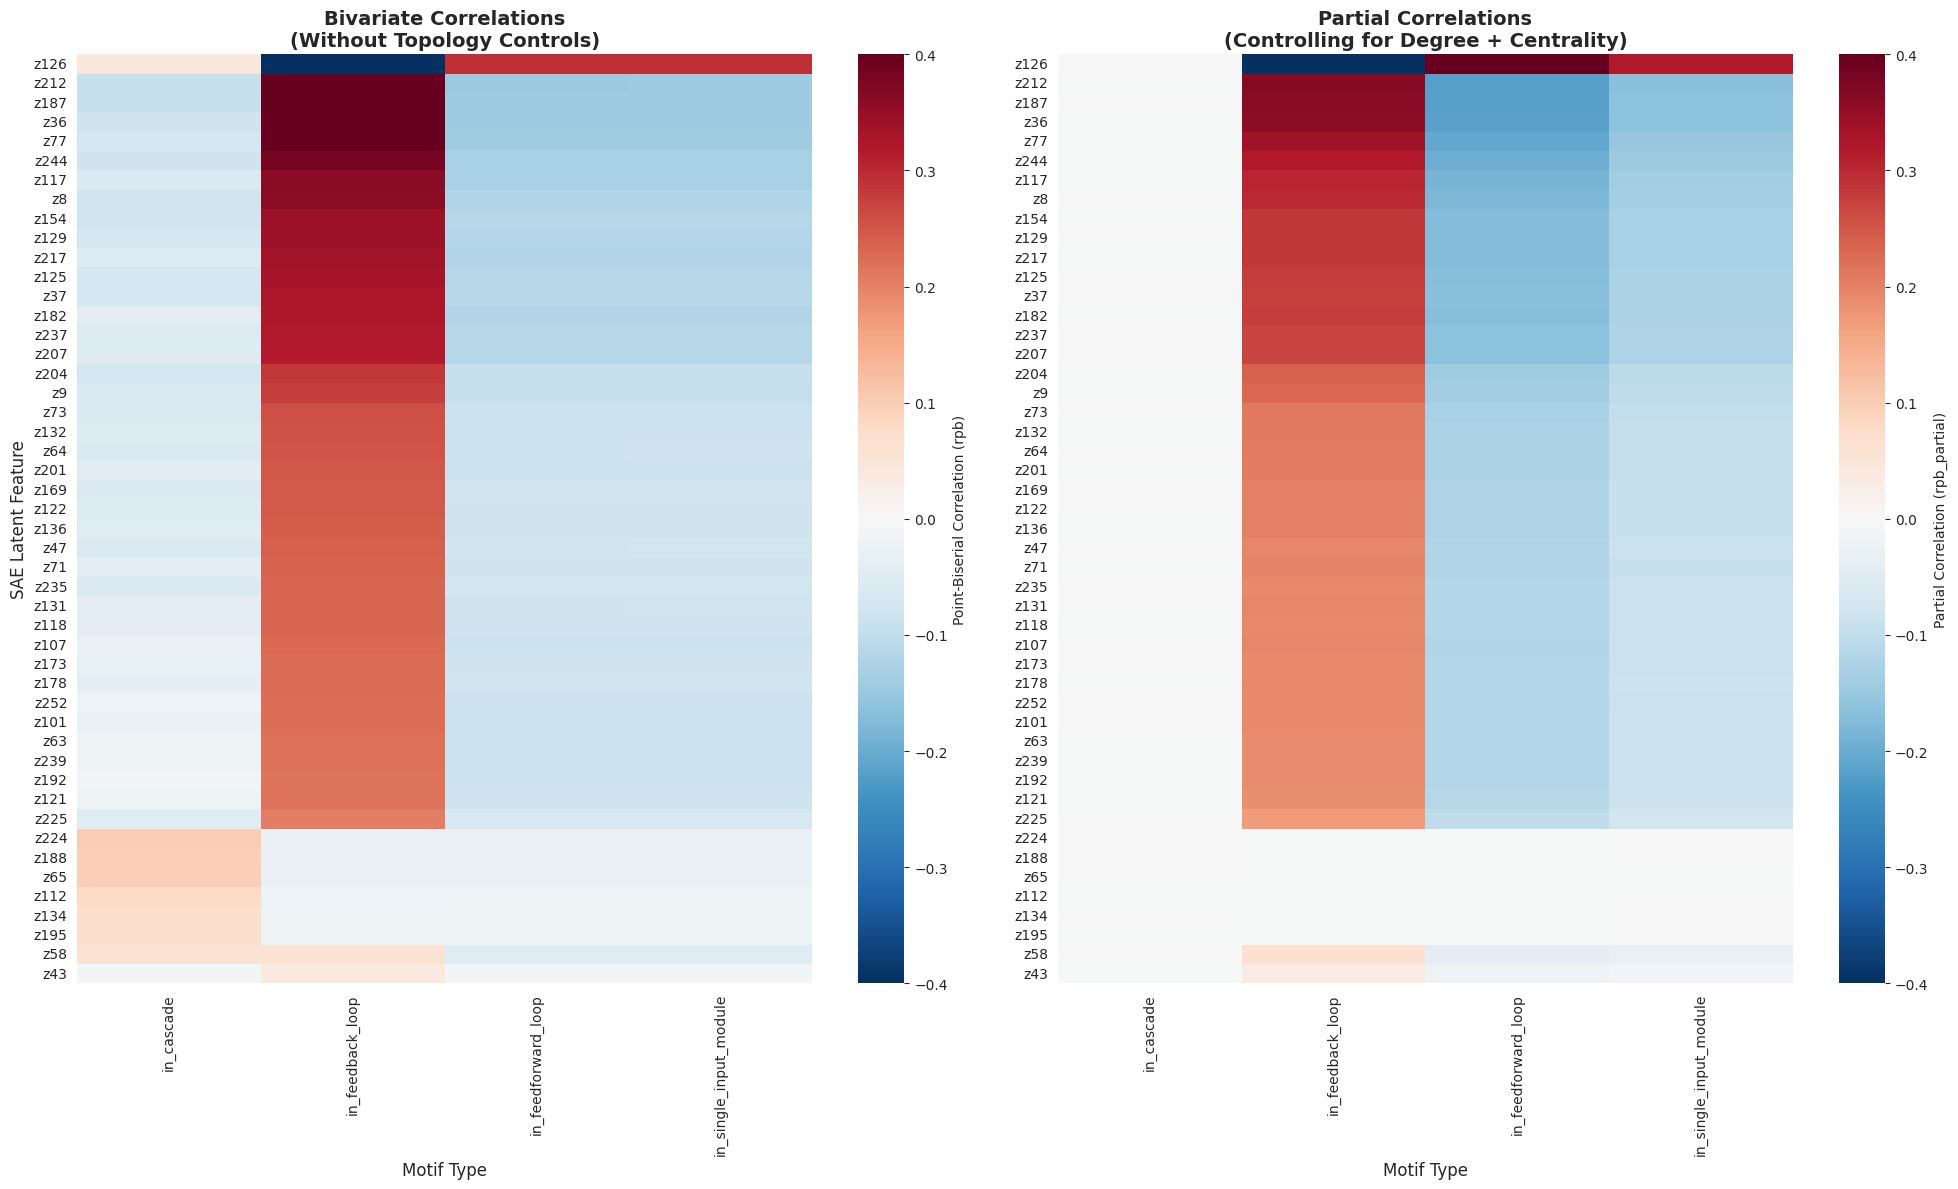

In [19]:
# Plot 1: Correlation heatmap
fig, axes = plt.subplots(1, 2 if use_partial else 1, figsize=(20 if use_partial else 10, 12))
if not use_partial:
    axes = [axes]

# Get top 50 features
max_corrs = corr_matrix.abs().max(axis=1)
top_features = max_corrs.nlargest(50).index

# Bivariate
ax = axes[0]
sns.heatmap(corr_matrix.loc[top_features], 
            cmap='RdBu_r', center=0, vmin=-0.4, vmax=0.4,
            cbar_kws={'label': 'Point-Biserial Correlation (rpb)'},
            ax=ax)
ax.set_title('Bivariate Correlations\n(Without Topology Controls)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Motif Type', fontsize=12)
ax.set_ylabel('SAE Latent Feature', fontsize=12)

# Partial (if available)
if use_partial:
    ax = axes[1]
    sns.heatmap(corr_matrix_partial.loc[top_features], 
                cmap='RdBu_r', center=0, vmin=-0.4, vmax=0.4,
                cbar_kws={'label': 'Partial Correlation (rpb_partial)'},
                ax=ax)
    ax.set_title('Partial Correlations\n(Controlling for Degree + Centrality)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Motif Type', fontsize=12)
    ax.set_ylabel('', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/paper_figures/feature_motif_heatmap_with_controls.png', dpi=150, bbox_inches='tight')
plt.show()

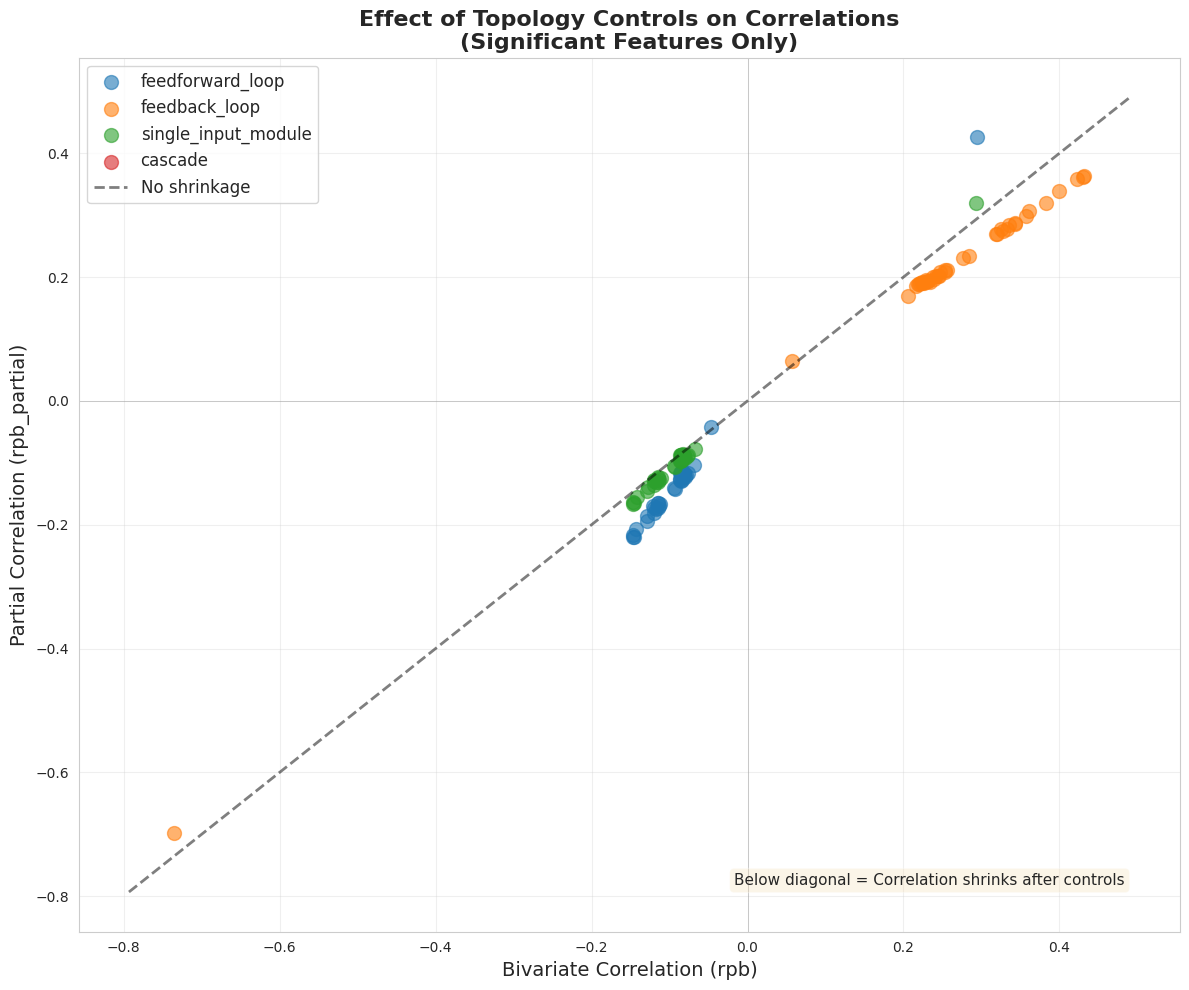

In [20]:
# Plot 2: Bivariate vs Partial Scatter (if controls enabled)
if use_partial:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    for motif in motif_types:
        motif_data = df_corr[(df_corr['motif'] == motif) & (df_corr['significant_fdr'])].dropna(subset=['rpb_partial'])
        ax.scatter(motif_data['rpb'], motif_data['rpb_partial'], 
                  alpha=0.6, s=100, label=motif.replace('in_', ''))
    
    # Diagonal line (rpb = rpb_partial)
    lims = [ax.get_xlim()[0], ax.get_xlim()[1]]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='No shrinkage')
    
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Bivariate Correlation (rpb)', fontsize=14)
    ax.set_ylabel('Partial Correlation (rpb_partial)', fontsize=14)
    ax.set_title('Effect of Topology Controls on Correlations\n(Significant Features Only)', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Add text annotation
    ax.text(0.95, 0.05, 'Below diagonal = Correlation shrinks after controls',
            transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig('outputs/paper_figures/bivariate_vs_partial_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

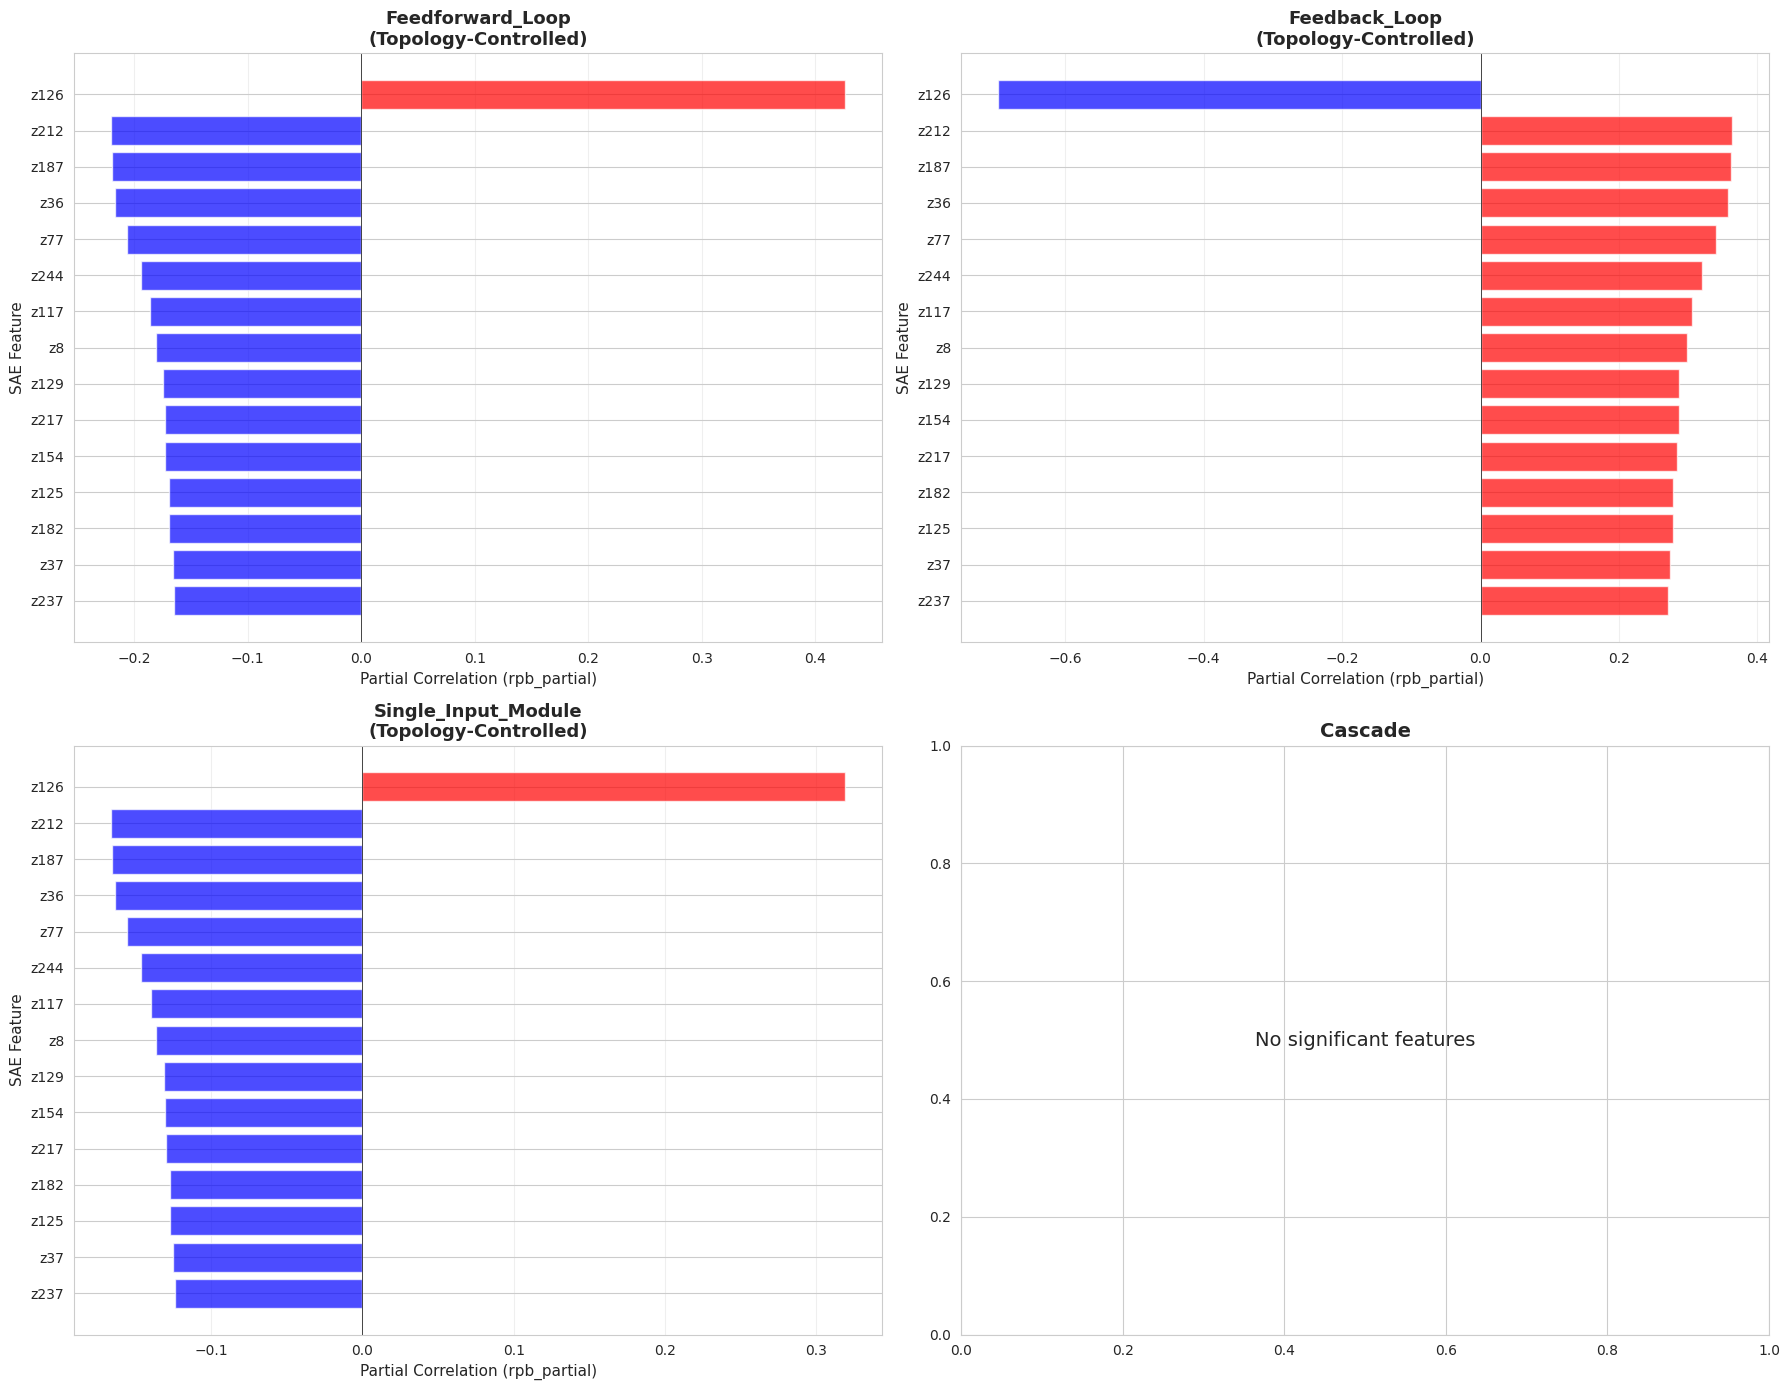

In [21]:
# Plot 3: Top features for each motif (using partial if available)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for idx, motif in enumerate(motif_types):
    ax = axes[idx]
    
    # Get top 15 significant features
    motif_corrs = df_corr[
        (df_corr['motif'] == motif) & 
        (df_corr['significant_fdr'])
    ].nlargest(15, test_corr_abs_col)
    
    if len(motif_corrs) == 0:
        ax.text(0.5, 0.5, 'No significant features', 
                ha='center', va='center', fontsize=14)
        ax.set_title(f'{motif.replace("in_", "").title()}', 
                     fontsize=14, fontweight='bold')
        continue
    
    # Create bar plot
    corr_vals = motif_corrs[test_corr_col].values
    colors = ['red' if c > 0 else 'blue' for c in corr_vals]
    
    ax.barh(range(len(motif_corrs)), corr_vals, color=colors, alpha=0.7)
    ax.set_yticks(range(len(motif_corrs)))
    ax.set_yticklabels(motif_corrs['feature'])
    
    xlabel = 'Partial Correlation (rpb_partial)' if use_partial else 'Correlation (rpb)'
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('SAE Feature', fontsize=11)
    
    title = f'{motif.replace("in_", "").title()}'
    if use_partial:
        title += '\n(Topology-Controlled)'
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/paper_figures/top_features_per_motif_with_controls.png', dpi=150, bbox_inches='tight')
plt.show()

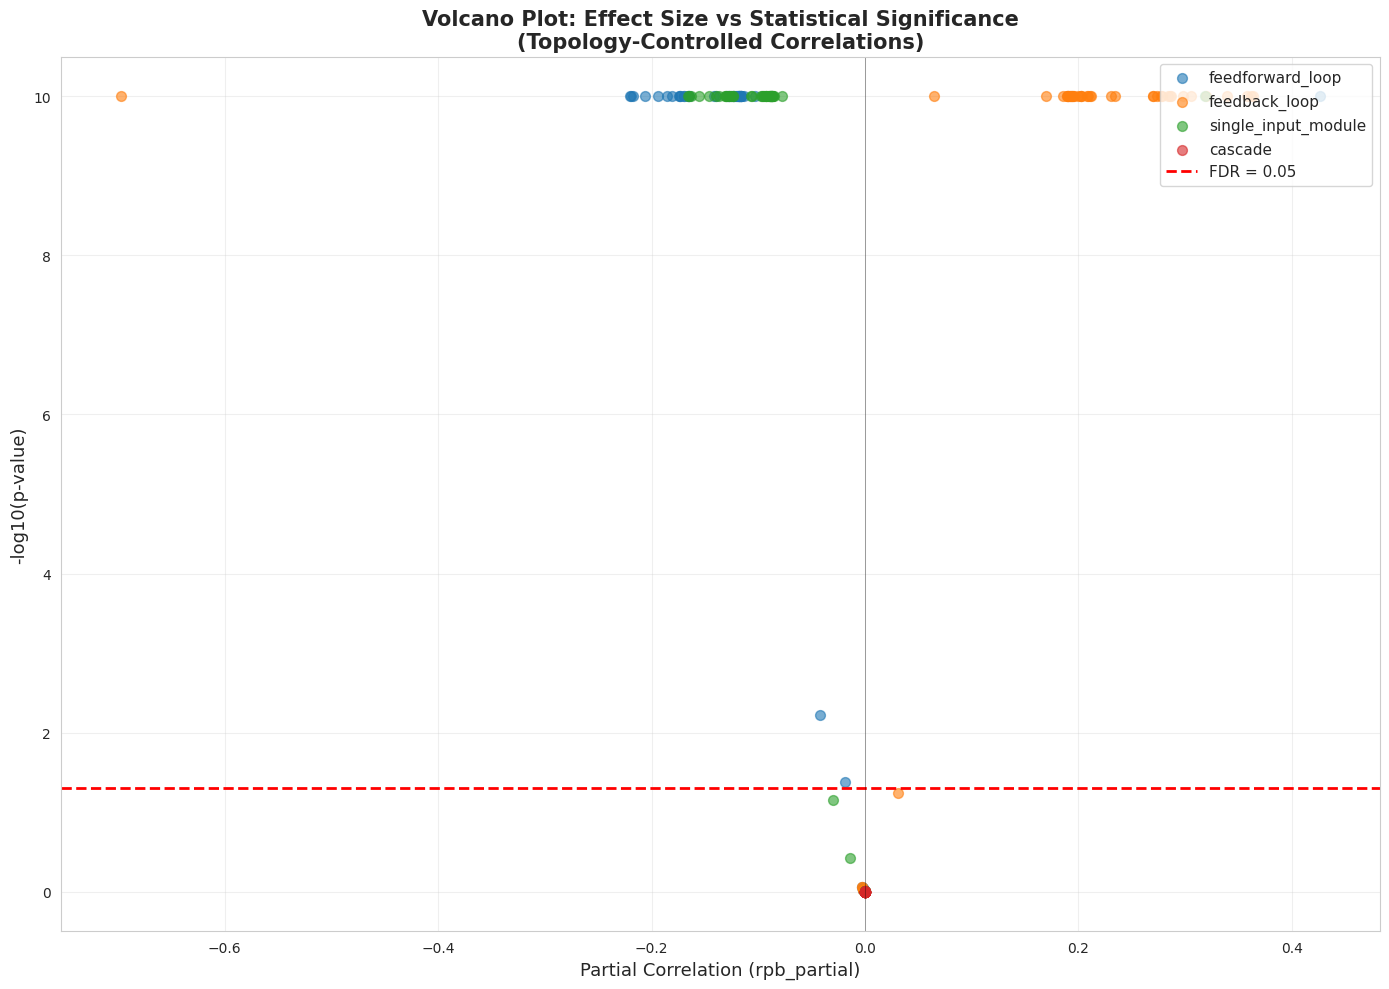

In [22]:
# Plot 4: Volcano plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

for motif in motif_types:
    motif_data = df_corr[df_corr['motif'] == motif].dropna(subset=['p_empirical'])
    neg_log_p = -np.log10(motif_data['p_empirical'].replace(0, 1e-10))
    
    ax.scatter(motif_data[test_corr_col], neg_log_p, 
              alpha=0.6, s=50, label=motif.replace('in_', ''))

sig_threshold = -np.log10(SIGNIFICANCE_LEVEL)
ax.axhline(y=sig_threshold, color='red', linestyle='--', 
           linewidth=2, label=f'FDR = {SIGNIFICANCE_LEVEL}')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

xlabel = 'Partial Correlation (rpb_partial)' if use_partial else 'Correlation (rpb)'
title = 'Volcano Plot: Effect Size vs Statistical Significance'
if use_partial:
    title += '\n(Topology-Controlled Correlations)'

ax.set_xlabel(xlabel, fontsize=13)
ax.set_ylabel('-log10(p-value)', fontsize=13)
ax.set_title(title, fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/paper_figures/volcano_plot_with_controls.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

This analysis evaluated SAE feature-motif correspondence with rigorous **degree + centrality controls**:

### Methodology:
1. **Sanity check** - Quantified topology-motif correlations to assess confounding
2. **Partial correlations** - Controlled for 9 topological features (degree, betweenness, closeness, PageRank, clustering)
3. **Permutation testing** - Tested significance of partial correlations (not bivariate)
4. **FDR correction** - Controlled false discovery rate at 5%

### Key Findings:
- **Confound strength**: (See sanity check output above)
- **Correlation shrinkage**: Average reduction after controls shows how much topology was confounding
- **True motif signal**: Features with high partial correlations capture motif semantics beyond topology

### Interpretation:
- **High rpb_partial** (>0.3): Feature captures motif-specific patterns
- **Low rpb_partial** but high rpb: Feature detects topology, not motif semantics
- **Similar rpb and rpb_partial**: Motif signal is independent of topology

### For Paper:
- Report **partial correlations** (rpb_partial), not bivariate
- Show before/after comparison to demonstrate importance of controls
- Cite topology-motif correlations as justification for controls